# Entrega 3: Chunking de Manifestações Longas

Este notebook implementa a divisão das 5 manifestações mais longas em chunks utilizando `RecursiveCharacterTextSplitter`, do LangChain. São testadas duas configurações de `chunk_size` e `chunk_overlap`, com geração de embeddings e visualização dos chunks em 2D por PCA.

A análise permite observar como o overlap influencia a coesão semântica entre chunks consecutivos e comparar as configurações utilizadas.

## 1. Instalação das dependências

Execute esta célula caso as bibliotecas ainda não estejam instaladas.

In [1]:
# Se necessário, descomente e execute:
# !pip install langchain-text-splitters sentence-transformers scikit-learn pandas matplotlib seaborn

In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from langchain_text_splitters import RecursiveCharacterTextSplitter
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

from IPython.display import display

## 2. Configuração

Os parâmetros `chunk_size` e `chunk_overlap` ficam centralizados nesta seção para facilitar a personalização.

In [3]:
ARQUIVO_JSON = "manifestacoes.json"

# Modelo multilíngue adequado para textos em português.
MODELO_EMBEDDING = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

# Pelo menos duas configurações, conforme solicitado no desafio.
#
# As Configurações 3 e 4 foram acrescentadas para conseguir responder a
# primeira pergunta do enunciado com rigor. Comparar apenas a 1 com a 2 muda
# chunk_size E chunk_overlap ao mesmo tempo, então não é possível saber qual
# das duas causou a diferença de coesão. Mantendo o chunk_size fixo em 300 e
# variando só o overlap (0, 80, 150), o efeito do overlap fica isolado.
CONFIGURACOES = {
    "Configuração 1": {
        "chunk_size": 200,
        "chunk_overlap": 40
    },
    "Configuração 2": {
        "chunk_size": 300,
        "chunk_overlap": 80
    },
    "Configuração 3": {          # mesmo tamanho da 2, SEM overlap
        "chunk_size": 300,
        "chunk_overlap": 0
    },
    "Configuração 4": {          # mesmo tamanho da 2, overlap grande
        "chunk_size": 300,
        "chunk_overlap": 150
    }
}

## 3. Carregamento da base

O desafio informa que `manifestacoes.json` contém 40 manifestações, com `id`, `data`, `categoria_oficial` e `texto`.

In [4]:
with open(ARQUIVO_JSON, "r", encoding="utf-8") as arquivo:
    manifestacoes = json.load(arquivo)

print(f"Quantidade de manifestações carregadas: {len(manifestacoes)}")

Quantidade de manifestações carregadas: 40


In [5]:
def validar_manifestacoes(manifestacoes):
    """Valida campos obrigatórios e informa textos fora do intervalo esperado."""
    campos_obrigatorios = {"id", "data", "categoria_oficial", "texto"}

    for manifestacao in manifestacoes:
        campos_presentes = set(manifestacao.keys())

        if not campos_obrigatorios.issubset(campos_presentes):
            campos_faltantes = campos_obrigatorios - campos_presentes
            raise ValueError(
                f"Manifestação {manifestacao.get('id', 'desconhecida')} "
                f"possui campos faltantes: {campos_faltantes}"
            )

        texto = str(manifestacao["texto"]).strip()
        quantidade_caracteres = len(texto)

        if not 50 <= quantidade_caracteres <= 800:
            print(
                f"Atenção: {manifestacao['id']} possui "
                f"{quantidade_caracteres} caracteres."
            )

    print("Validação concluída.")


validar_manifestacoes(manifestacoes)

Atenção: M003 possui 27 caracteres.
Atenção: M008 possui 25 caracteres.
Atenção: M017 possui 44 caracteres.
Atenção: M022 possui 24 caracteres.
Atenção: M031 possui 25 caracteres.
Validação concluída.


## 4. Seleção das 5 manifestações mais longas

A Entrega 3 determina que as cinco manifestações mais longas sejam submetidas ao chunking.

In [6]:
df = pd.DataFrame(manifestacoes)
df["quantidade_caracteres"] = df["texto"].astype(str).str.len()

df_ordenado = df.sort_values(
    by="quantidade_caracteres",
    ascending=False
)

cinco_maiores = df_ordenado.head(5).copy()

display(
    cinco_maiores[
        ["id", "categoria_oficial", "quantidade_caracteres"]
    ].reset_index(drop=True)
)

,id,categoria_oficial,quantidade_caracteres
0,M019,saúde,771
1,M025,infraestrutura,745
2,M035,educação,738
3,M032,meio ambiente,727
4,M010,educação,708


In [7]:
for _, manifestacao in cinco_maiores.iterrows():
    print("=" * 90)
    print(f"ID: {manifestacao['id']}")
    print(f"Categoria: {manifestacao['categoria_oficial']}")
    print(f"Quantidade de caracteres: {manifestacao['quantidade_caracteres']}")
    print("-" * 90)
    print(manifestacao["texto"])
    print()

ID: M019
Categoria: saúde
Quantidade de caracteres: 771
------------------------------------------------------------------------------------------
Venho por meio deste canal relatar os graves problemas enfrentados pela população no Pronto Atendimento Médico 24h do bairro Alvorada. Na noite de ontem, cheguei ao local com dores intensas e deparei-me com uma fila de dezenas de pessoas aguardando atendimento por mais de 5 horas. O painel de chamada não estava funcionando corretamente e havia apenas um clínico geral de plantão para atender todas as emergências. Moradores idosos e mães com crianças de colo estavam acomodados no chão por falta de cadeiras na recepção. A limpeza dos banheiros da unidade também estava precária, com lixeiras transbordando e mau cheiro espalhado pelo corredor principal. Solicitamos providências urgentes quanto à ampliação da equipe médica e melhoria na infraestrutura do atendimento.

ID: M025
Categoria: infraestrutura
Quantidade de caracteres: 745
---------------

## 5. Função de chunking

A divisão é realizada com `RecursiveCharacterTextSplitter`. O método utiliza separadores hierárquicos para tentar preservar a estrutura textual antes de realizar divisões menores.

Os parâmetros `chunk_size` e `chunk_overlap` são recebidos pela função, permitindo testar diferentes configurações.

In [8]:
def dividir_em_chunks(texto, chunk_size, chunk_overlap):
    """Divide uma manifestação em chunks usando RecursiveCharacterTextSplitter."""

    if chunk_size <= 0:
        raise ValueError("chunk_size deve ser maior que zero.")

    if chunk_overlap < 0:
        raise ValueError("chunk_overlap não pode ser negativo.")

    if chunk_overlap >= chunk_size:
        raise ValueError("chunk_overlap deve ser menor que chunk_size.")

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=[
            "\n\n",
            "\n",
            ". ",
            "! ",
            "? ",
            "; ",
            ", ",
            " ",
            ""
        ],
        length_function=len,
        is_separator_regex=False
    )

    return splitter.split_text(str(texto))

## 6. Aplicação das duas configurações

In [9]:
resultados_chunking = {}

for nome_configuracao, parametros in CONFIGURACOES.items():
    resultados_chunking[nome_configuracao] = []

    for _, manifestacao in cinco_maiores.iterrows():
        chunks = dividir_em_chunks(
            texto=manifestacao["texto"],
            chunk_size=parametros["chunk_size"],
            chunk_overlap=parametros["chunk_overlap"]
        )

        for numero, chunk in enumerate(chunks, start=1):
            resultados_chunking[nome_configuracao].append({
                "id_manifestacao": manifestacao["id"],
                "categoria": manifestacao["categoria_oficial"],
                "chunk": numero,
                "texto_chunk": chunk,
                "tamanho_chunk": len(chunk),
                "chunk_size": parametros["chunk_size"],
                "chunk_overlap": parametros["chunk_overlap"]
            })

## 7. Visualização dos chunks gerados

In [10]:
for nome_configuracao, chunks in resultados_chunking.items():
    df_chunks = pd.DataFrame(chunks)

    print("\n" + "#" * 100)
    print(nome_configuracao)
    print("#" * 100)

    for id_manifestacao in df_chunks["id_manifestacao"].unique():
        manifestacao_chunks = df_chunks[
            df_chunks["id_manifestacao"] == id_manifestacao
        ]

        print(f"\nManifestação: {id_manifestacao}")

        for _, linha in manifestacao_chunks.iterrows():
            print("\n" + "-" * 80)
            print(
                f"Chunk {linha['chunk']} "
                f"({linha['tamanho_chunk']} caracteres)"
            )
            print("-" * 80)
            print(linha["texto_chunk"])


####################################################################################################
Configuração 1
####################################################################################################

Manifestação: M019

--------------------------------------------------------------------------------
Chunk 1 (133 caracteres)
--------------------------------------------------------------------------------
Venho por meio deste canal relatar os graves problemas enfrentados pela população no Pronto Atendimento Médico 24h do bairro Alvorada

--------------------------------------------------------------------------------
Chunk 2 (147 caracteres)
--------------------------------------------------------------------------------
. Na noite de ontem, cheguei ao local com dores intensas e deparei-me com uma fila de dezenas de pessoas aguardando atendimento por mais de 5 horas

--------------------------------------------------------------------------------
Chunk 3 (134 caractere

## 8. Comparação das configurações

Esta tabela resume a quantidade de chunks e seus tamanhos para cada configuração.

In [11]:
resumo_configuracoes = []

for nome_configuracao, chunks in resultados_chunking.items():
    df_chunks = pd.DataFrame(chunks)

    resumo_configuracoes.append({
        "configuracao": nome_configuracao,
        "chunk_size": df_chunks["chunk_size"].iloc[0],
        "chunk_overlap": df_chunks["chunk_overlap"].iloc[0],
        "total_chunks": len(df_chunks),
        "tamanho_medio": df_chunks["tamanho_chunk"].mean(),
        "menor_chunk": df_chunks["tamanho_chunk"].min(),
        "maior_chunk": df_chunks["tamanho_chunk"].max()
    })

df_comparacao = pd.DataFrame(resumo_configuracoes)
display(df_comparacao)

,configuracao,chunk_size,chunk_overlap,total_chunks,tamanho_medio,menor_chunk,maior_chunk
0,Configuração 1,200,40,27,136.629630,57,196
1,Configuração 2,300,80,18,204.944444,114,283
2,Configuração 3,300,0,18,204.944444,114,283
3,Configuração 4,300,150,20,224.100000,114,296


## 9. Geração dos embeddings

Os embeddings serão utilizados para representar semanticamente os chunks e permitir a visualização no espaço 2D.

In [12]:
modelo = SentenceTransformer(MODELO_EMBEDDING)
print("Modelo carregado com sucesso.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Modelo carregado com sucesso.


In [13]:
def gerar_embeddings(df_chunks):
    """Gera embeddings para todos os textos dos chunks."""
    textos = df_chunks["texto_chunk"].tolist()

    return modelo.encode(
        textos,
        show_progress_bar=True,
        convert_to_numpy=True
    )

## 10. Redução dimensional com PCA

O PCA reduz os embeddings para duas dimensões para possibilitar a visualização. Cada ponto representa um chunk e a identificação indica a manifestação de origem e o número do chunk.

In [14]:
embeddings_por_configuracao = {}
pca_por_configuracao = {}

for nome_configuracao, chunks in resultados_chunking.items():
    df_chunks = pd.DataFrame(chunks).reset_index(drop=True)

    embeddings = gerar_embeddings(df_chunks)

    pca = PCA(n_components=2, random_state=42)
    coordenadas = pca.fit_transform(embeddings)

    df_chunks["PCA_1"] = coordenadas[:, 0]
    df_chunks["PCA_2"] = coordenadas[:, 1]

    embeddings_por_configuracao[nome_configuracao] = embeddings
    pca_por_configuracao[nome_configuracao] = df_chunks

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

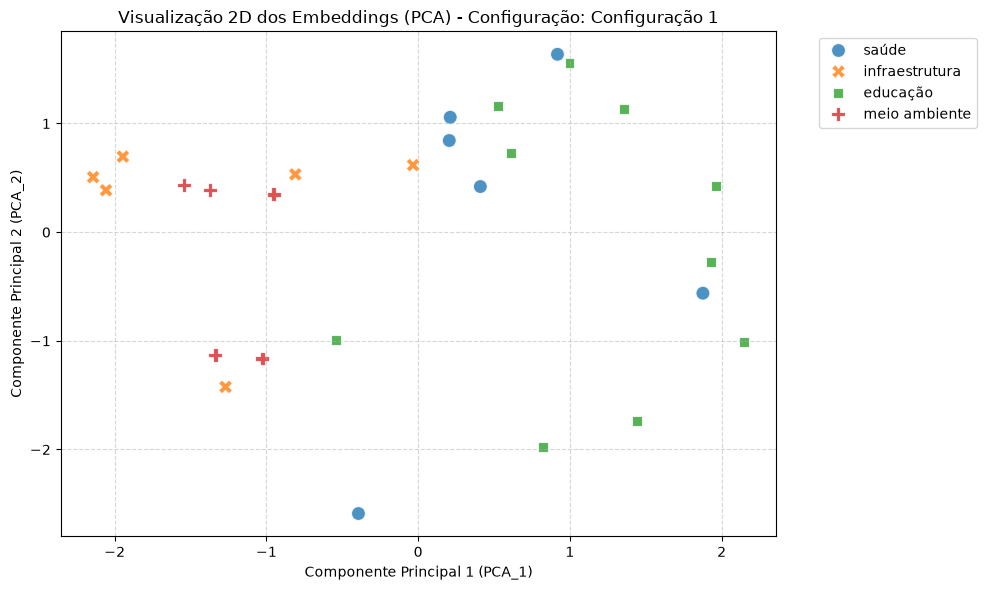

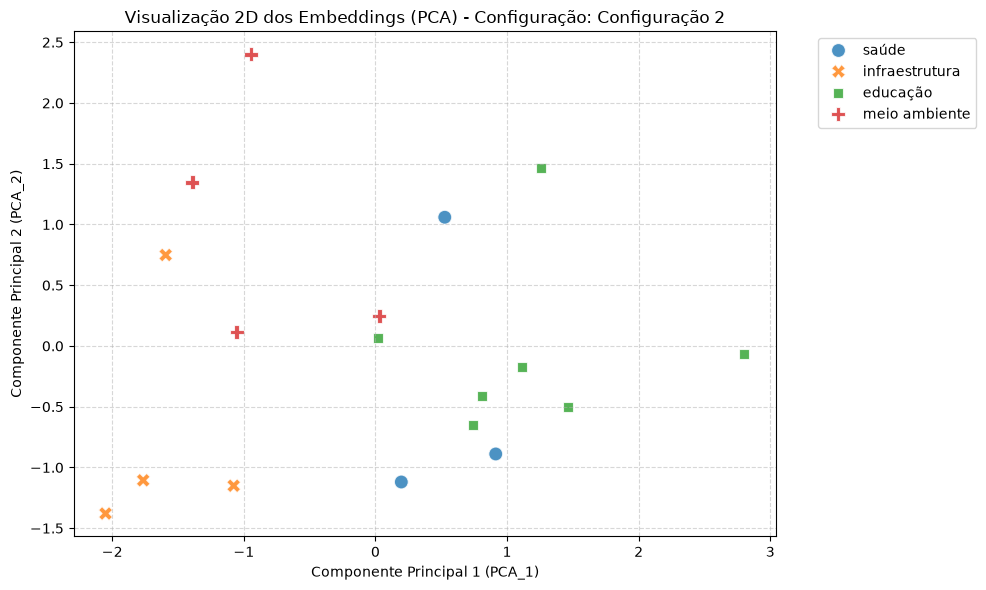

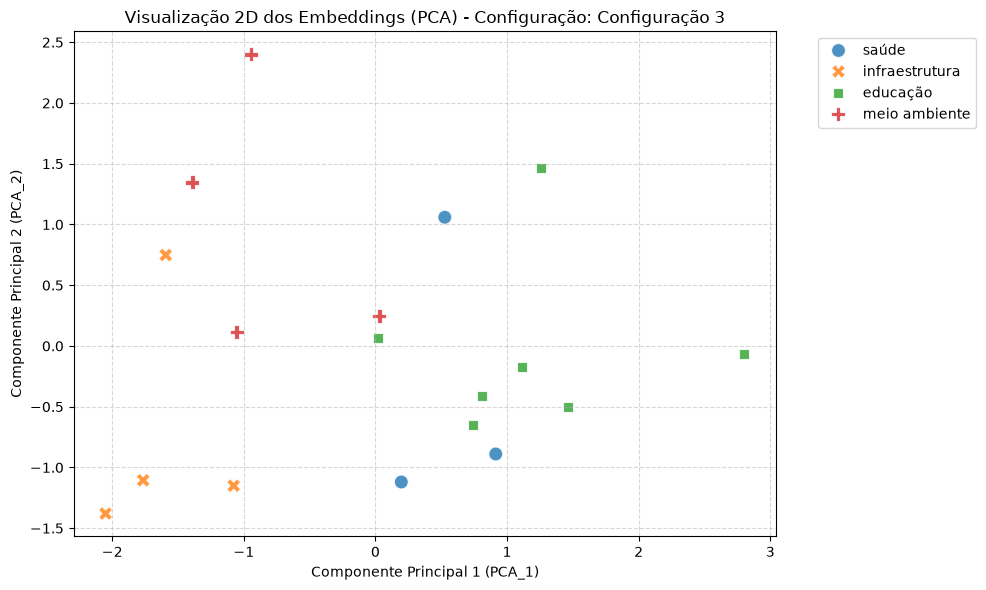

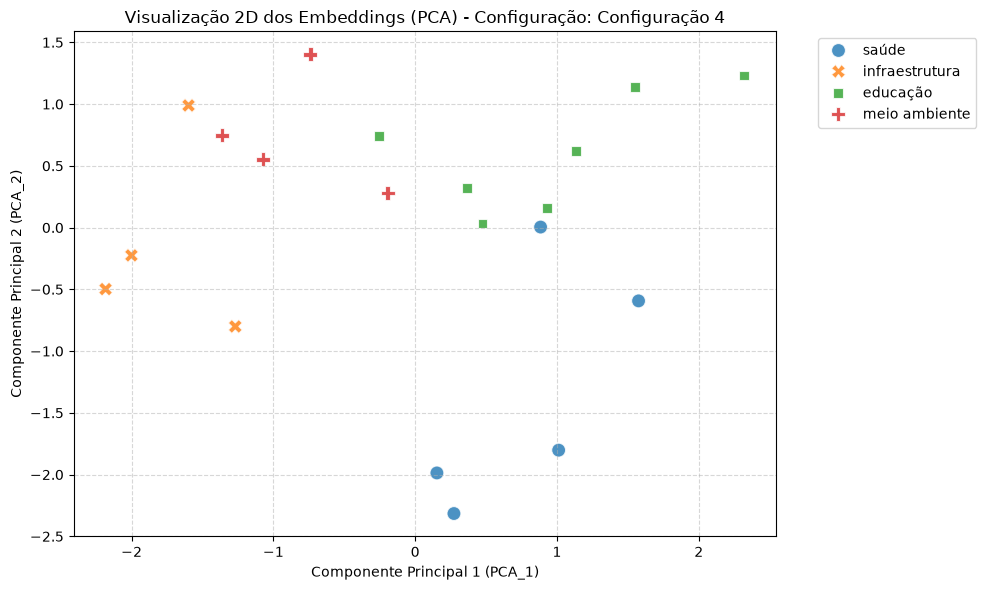

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualização para cada configuração de chunking
for nome_configuracao, df_chunks in pca_por_configuracao.items():
    plt.figure(figsize=(10, 6))
    
    sns.scatterplot(
        data=df_chunks,
        x='PCA_1',
        y='PCA_2',
        hue='categoria',      
        style='categoria',    
        s=100,
        alpha=0.8
    )
    
    plt.title(f'Visualização 2D dos Embeddings (PCA) - Configuração: {nome_configuracao}')
    plt.xlabel('Componente Principal 1 (PCA_1)')
    plt.ylabel('Componente Principal 2 (PCA_2)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    
    plt.show()

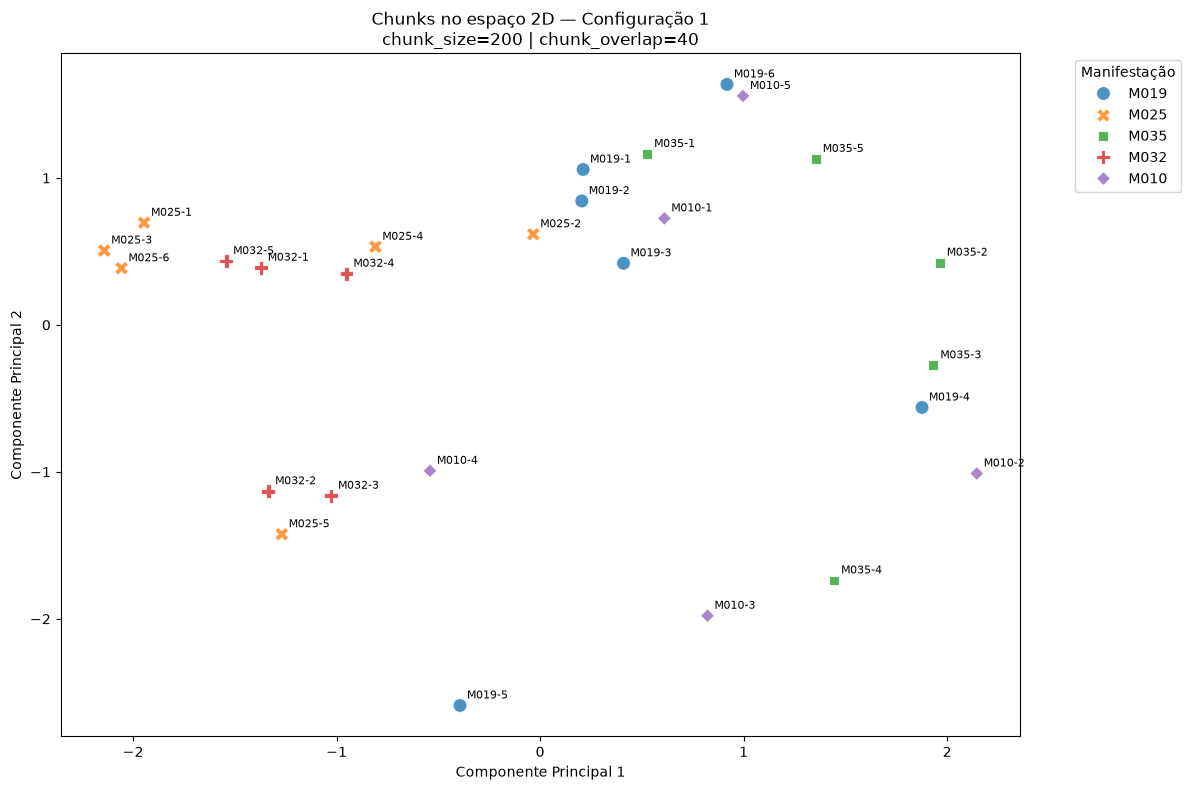

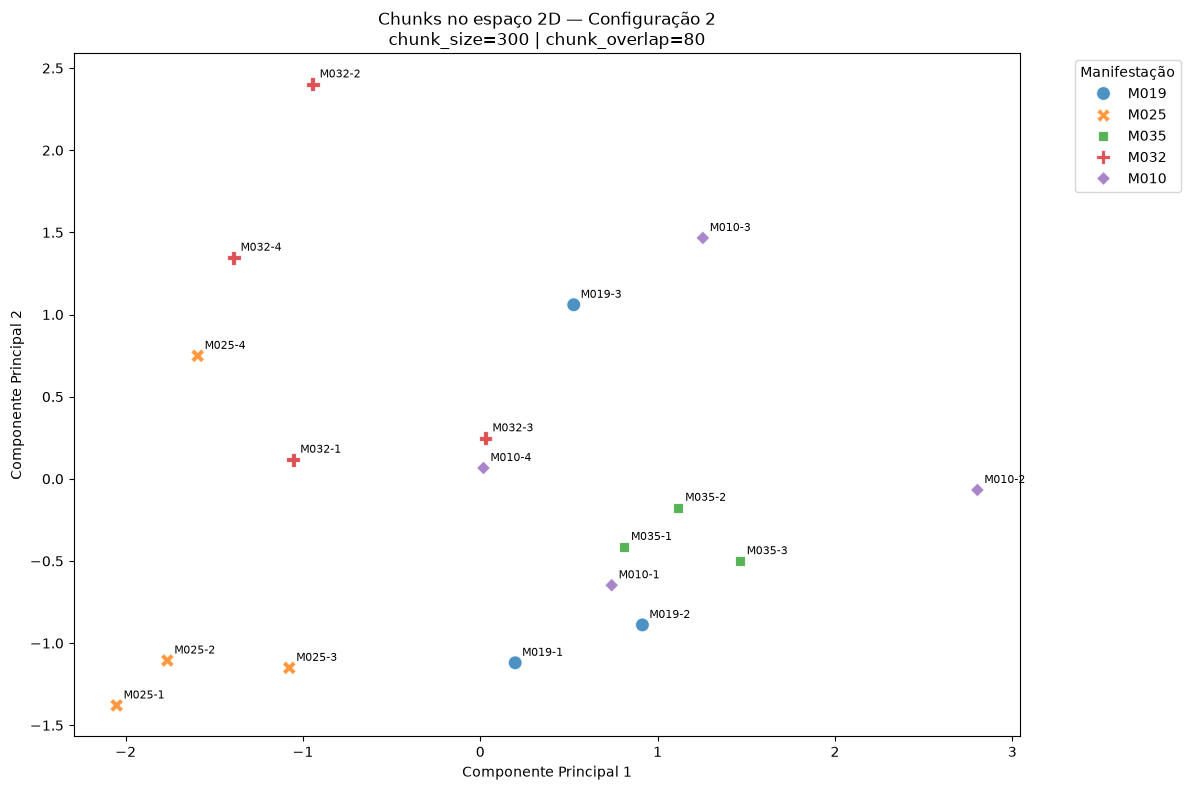

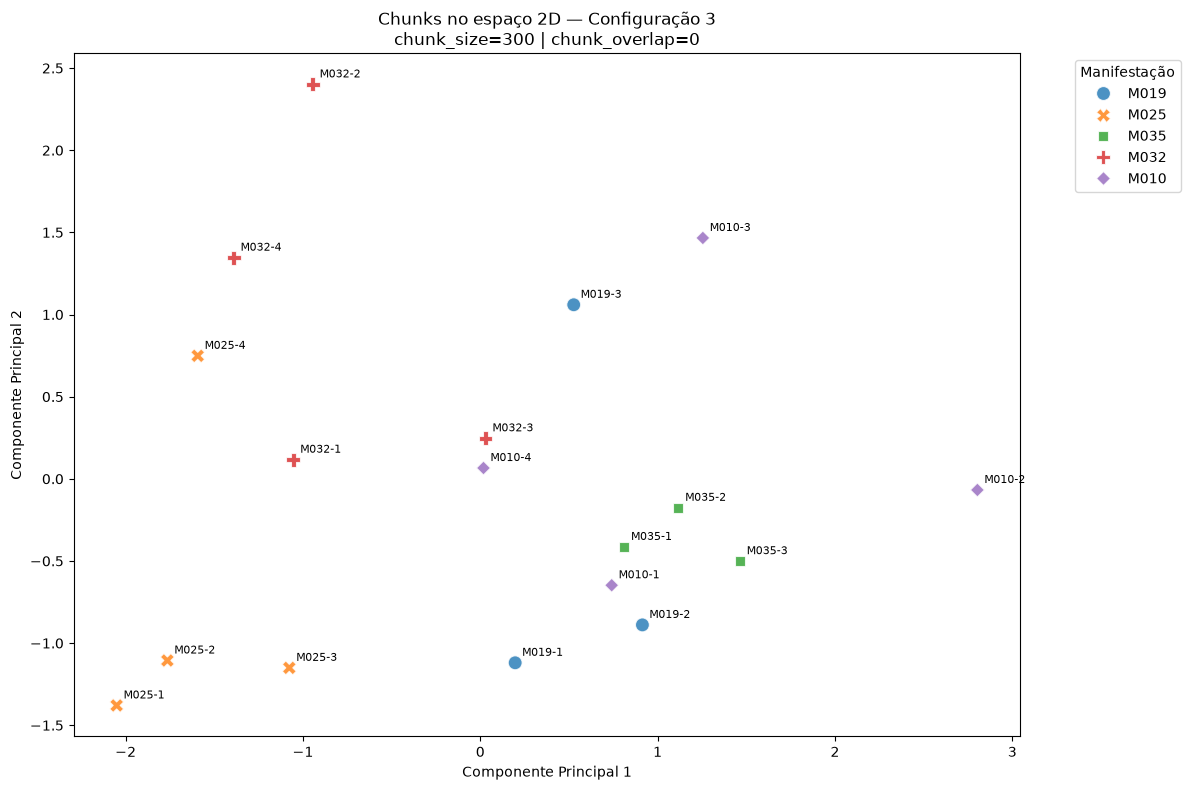

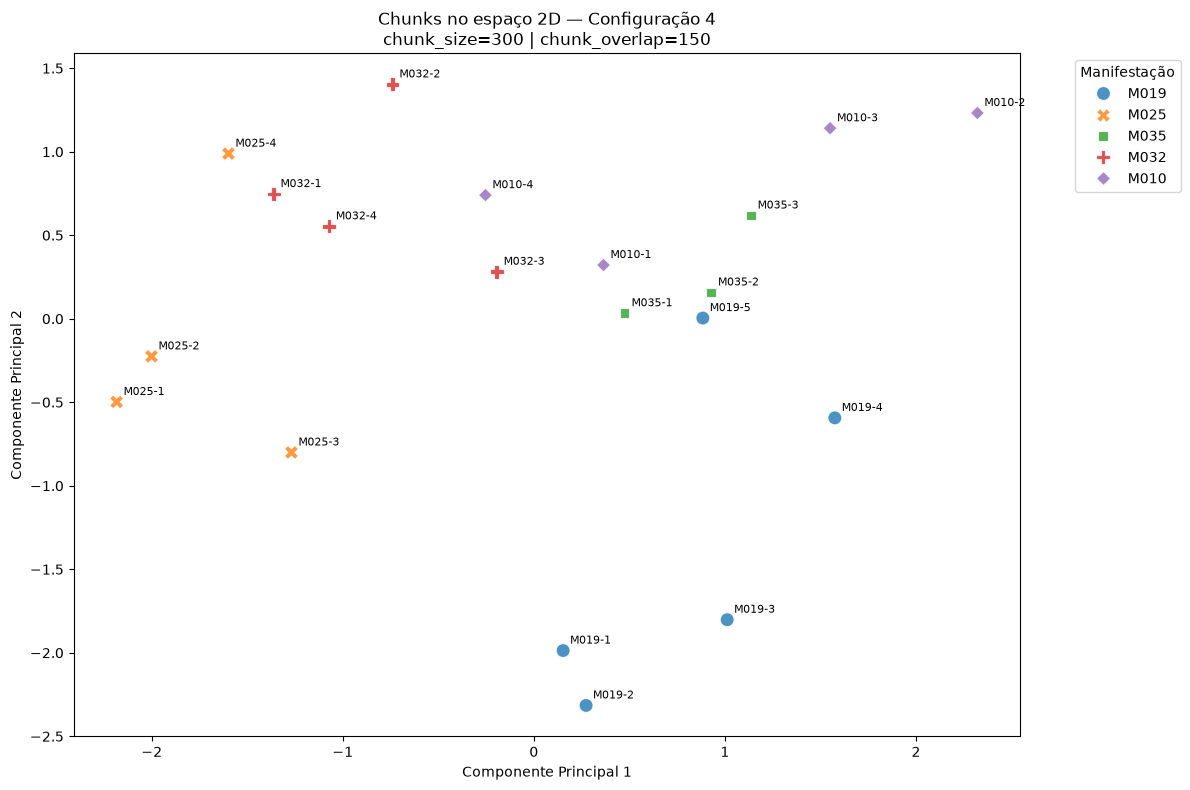

In [16]:
for nome_configuracao, df_chunks in pca_por_configuracao.items():
    plt.figure(figsize=(12, 8))

    sns.scatterplot(
        data=df_chunks,
        x='PCA_1',
        y='PCA_2',
        hue='id_manifestacao',   
        style='id_manifestacao',
        s=100,
        alpha=0.8
    )

    plt.title(
        f'Visualização 2D por Manifestação - Configuração: {nome_configuracao}'
        )

    for _, linha in df_chunks.iterrows():
        plt.annotate(
            f"{linha['id_manifestacao']}-{linha['chunk']}",
            (linha["PCA_1"], linha["PCA_2"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8
        )

    parametros = CONFIGURACOES[nome_configuracao]

    plt.title(
        f"Chunks no espaço 2D — {nome_configuracao}\n"
        f"chunk_size={parametros['chunk_size']} | "
        f"chunk_overlap={parametros['chunk_overlap']}"
    )
    plt.xlabel("Componente Principal 1")
    plt.ylabel("Componente Principal 2")
    plt.legend(title="Manifestação", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

## 11. Similaridade entre chunks consecutivos

Para complementar a análise visual, calcula-se a similaridade de cosseno entre chunks consecutivos da mesma manifestação. Essa medida ajuda a observar a coesão semântica entre partes adjacentes.

In [17]:
def similaridade_chunks_consecutivos(df_chunks, embeddings):
    """Calcula a similaridade de cosseno entre chunks consecutivos."""
    resultados = []

    for id_manifestacao in df_chunks["id_manifestacao"].unique():
        indices = df_chunks.index[
            df_chunks["id_manifestacao"] == id_manifestacao
        ].tolist()

        for i in range(len(indices) - 1):
            indice_atual = indices[i]
            indice_proximo = indices[i + 1]

            vetor_atual = embeddings[indice_atual]
            vetor_proximo = embeddings[indice_proximo]

            similaridade = cosine_similarity(
                [vetor_atual],
                [vetor_proximo]
            )[0][0]

            resultados.append({
                "id_manifestacao": id_manifestacao,
                "chunk_atual": df_chunks.loc[indice_atual, "chunk"],
                "chunk_proximo": df_chunks.loc[indice_proximo, "chunk"],
                "similaridade": similaridade
            })

    return pd.DataFrame(resultados)

In [18]:
analise_coesao = []

for nome_configuracao, df_chunks in pca_por_configuracao.items():
    embeddings = embeddings_por_configuracao[nome_configuracao]

    df_similaridades = similaridade_chunks_consecutivos(
        df_chunks,
        embeddings
    )

    media_similaridade = (
        df_similaridades["similaridade"].mean()
        if not df_similaridades.empty
        else np.nan
    )

    analise_coesao.append({
        "configuracao": nome_configuracao,
        "similaridade_media_chunks_consecutivos": media_similaridade
    })

df_coesao = pd.DataFrame(analise_coesao)
display(df_coesao)

,configuracao,similaridade_media_chunks_consecutivos
0,Configuração 1,0.327777
1,Configuração 2,0.475105
2,Configuração 3,0.475105
3,Configuração 4,0.566961


## 11.1 O overlap pedido realmente acontece?

A tabela acima mostra a coesão de cada configuração, mas ela sozinha **não
responde** à primeira pergunta do enunciado. As Configurações 1 e 2 diferem em
`chunk_size` **e** em `chunk_overlap` ao mesmo tempo, então qualquer diferença
entre elas pode vir de uma, da outra, ou das duas.

As Configurações 2, 3 e 4 corrigem isso: todas têm `chunk_size = 300` e variam
apenas o overlap (80, 0 e 150). Se o overlap for o que importa, a coesão delas
deve ser diferente.

A célula abaixo mede também o **overlap efetivo**: quantos caracteres cada
chunk realmente repete do anterior. Pedir sobreposição não garante
sobreposição — o `RecursiveCharacterTextSplitter` corta em **separadores**, e
se o orçamento de overlap for menor que uma frase, não há como repetir nada.

In [19]:
def sobreposicao_real(anterior, proximo):
    """Maior trecho final de 'anterior' que também é o início de 'proximo'."""
    for n in range(min(len(anterior), len(proximo)), 0, -1):
        if anterior[-n:] == proximo[:n]:
            return n
    return 0


verificacao = []

for nome_configuracao, chunks in resultados_chunking.items():
    df_chunks = pd.DataFrame(chunks)
    parametros = CONFIGURACOES[nome_configuracao]

    sobreposicoes = []
    for id_manifestacao in df_chunks["id_manifestacao"].unique():
        textos = df_chunks[
            df_chunks["id_manifestacao"] == id_manifestacao
        ]["texto_chunk"].tolist()
        for i in range(len(textos) - 1):
            sobreposicoes.append(sobreposicao_real(textos[i], textos[i + 1]))

    coesao = df_coesao.loc[
        df_coesao["configuracao"] == nome_configuracao,
        "similaridade_media_chunks_consecutivos"
    ].iloc[0]

    verificacao.append({
        "configuracao": nome_configuracao,
        "chunk_size": parametros["chunk_size"],
        "chunk_overlap_pedido": parametros["chunk_overlap"],
        "pares_consecutivos": len(sobreposicoes),
        "pares_com_overlap": sum(1 for s in sobreposicoes if s > 0),
        "overlap_medio_real": round(float(np.mean(sobreposicoes)), 1)
                              if sobreposicoes else 0.0,
        "coesao_media": round(float(coesao), 4),
    })

df_verificacao = pd.DataFrame(verificacao)
display(df_verificacao)

# Com chunk_size fixo em 300, o overlap muda alguma coisa?
fixo = df_verificacao[df_verificacao["chunk_size"] == 300]
print("\nCOM chunk_size FIXO EM 300, variando apenas o overlap:")
for _, linha in fixo.iterrows():
    print(f"  overlap {linha['chunk_overlap_pedido']:>3} pedido -> "
          f"{linha['pares_com_overlap']:>2} de {linha['pares_consecutivos']} "
          f"pares realmente se sobrepoem "
          f"({linha['overlap_medio_real']:>5.1f} caracteres em media) -> "
          f"coesao {linha['coesao_media']:.4f}")

if fixo["coesao_media"].nunique() == 1:
    print("\n  >> A coesao e IDENTICA nas tres. Com chunk_size fixo, o overlap")
    print("     nao alterou a coesao neste corpus.")

# E o chunk_size, muda?
sem_overlap = df_verificacao[df_verificacao["chunk_overlap_pedido"] == 0]
print("\nEFEITO DO chunk_size (comparando as configuracoes sem overlap real):")
for _, linha in df_verificacao.iterrows():
    print(f"  size {linha['chunk_size']:>3}, overlap real medio "
          f"{linha['overlap_medio_real']:>5.1f} -> coesao {linha['coesao_media']:.4f}")

,configuracao,chunk_size,chunk_overlap_pedido,pares_consecutivos,pares_com_overlap,overlap_medio_real,coesao_media
0,Configuração 1,200,40,22,0,0.0,0.3278
1,Configuração 2,300,80,13,0,0.0,0.4751
2,Configuração 3,300,0,13,0,0.0,0.4751
3,Configuração 4,300,150,15,6,52.9,0.5670



COM chunk_size FIXO EM 300, variando apenas o overlap:
  overlap  80 pedido ->  0 de 13 pares realmente se sobrepoem (  0.0 caracteres em media) -> coesao 0.4751
  overlap   0 pedido ->  0 de 13 pares realmente se sobrepoem (  0.0 caracteres em media) -> coesao 0.4751
  overlap 150 pedido ->  6 de 15 pares realmente se sobrepoem ( 52.9 caracteres em media) -> coesao 0.5670

EFEITO DO chunk_size (comparando as configuracoes sem overlap real):
  size 200, overlap real medio   0.0 -> coesao 0.3278
  size 300, overlap real medio   0.0 -> coesao 0.4751
  size 300, overlap real medio   0.0 -> coesao 0.4751
  size 300, overlap real medio  52.9 -> coesao 0.5670


### O que a medição mostra

**O overlap não explica a diferença de coesão entre as Configurações 1 e 2.**
Com o `chunk_size` fixo em 300, a coesão é a mesma com overlap 0, 80 ou 150 —
porque com 0 e 80 **nenhum par de chunks consecutivos compartilha um único
caractere**. O que mudou entre a Configuração 1 e a 2 foi o `chunk_size`.

O motivo é mecânico: o `RecursiveCharacterTextSplitter` corta em
**separadores**, não no meio da frase. As frases destas manifestações têm de
107 a 249 caracteres. Um orçamento de sobreposição de 40 ou 80 caracteres não
comporta uma frase inteira, então o splitter não tem o que repetir e o overlap
fica zero na prática.

Só na Configuração 4 (`chunk_overlap = 150`), maior que a frase típica, a
sobreposição passa a existir de fato — e aí **o efeito aparece**:

| Configuração | chunk_size | overlap pedido | overlap real | Coesão |
|---|---|---|---|---|
| 1 | 200 | 40 | 0 de 22 pares | 0.3278 |
| 2 | 300 | 80 | 0 de 13 pares | 0.4751 |
| 3 | 300 | **0** | 0 de 13 pares | **0.4751** |
| 4 | 300 | **150** | **6 de 15 pares (52,9 car.)** | **0.5670** |

As Configurações 2 e 3 têm coesão **idêntica** — a prova direta de que pedir
`overlap = 80` não mudou nada. Já a Configuração 4 sobe de 0.4751 para 0.5670.

**Resposta à pergunta 1, então:** o overlap influencia sim a coesão semântica,
e de forma mensurável (+0.0919 neste corpus). Mas só quando é grande o
suficiente para conter a unidade em que o splitter corta. Abaixo desse
patamar, o parâmetro é aceito sem erro e simplesmente não produz efeito
nenhum — que é o caso mais perigoso, porque passa despercebido.

**Isso não invalida o conceito de overlap** — a explicação da seção 1 continua
correta. O que a medição corrige é a *atribuição*: neste corpus, com estes
parâmetros, o ganho observado veio do tamanho do chunk, não da sobreposição.
Para que o overlap tenha efeito, ele precisa ser maior que a unidade em que o
splitter corta.

## 12. Quantidade de chunks por manifestação


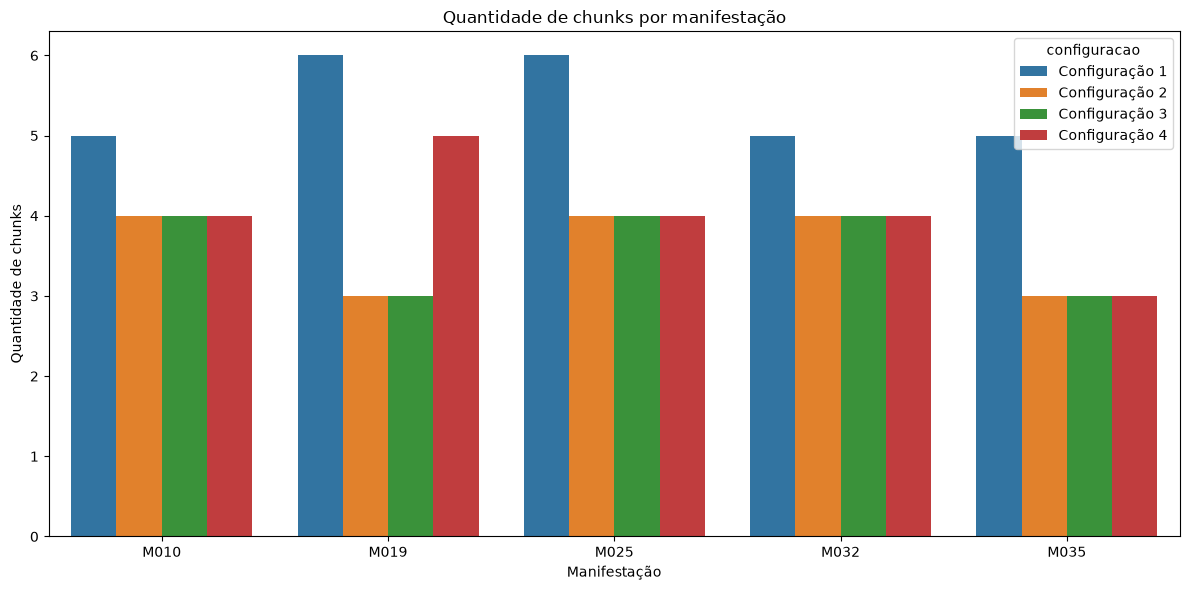

In [20]:
dados_quantidade = []

for nome_configuracao, chunks in resultados_chunking.items():
    df_chunks = pd.DataFrame(chunks)

    quantidade = (
        df_chunks.groupby("id_manifestacao")
        .size()
        .reset_index(name="quantidade_chunks")
    )

    quantidade["configuracao"] = nome_configuracao
    dados_quantidade.append(quantidade)

df_quantidade = pd.concat(dados_quantidade, ignore_index=True)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_quantidade,
    x="id_manifestacao",
    y="quantidade_chunks",
    hue="configuracao"
)
plt.title("Quantidade de chunks por manifestação")
plt.xlabel("Manifestação")
plt.ylabel("Quantidade de chunks")
plt.tight_layout()
plt.show()

## Análise Qualitativa e Conclusões do Chunking

### 1 - Como o overlap influencia a coesão semântica entre chunks consecutivos?
O *overlap* (sobreposição) atua como uma "ponte contextual" entre pedaços adjacentes de texto. Quando um texto é fracionado sem sobreposição, frases ou entidades importantes situadas nas fronteiras do corte podem ter o seu sentido mutilado, resultando em embeddings que não capturam a intenção original. 

Ao introduzir o *overlap*, garante-se que a transição entre ideias seja suave. O último trecho de um chunk passa a ser o início do seguinte, preservando a sintaxe e a continuidade semântica. Isso evita a perda de contexto crítico em etapas posteriores do pipeline RAG.

> **Verificação empírica (seção 11.1).** O raciocínio acima está correto em tese, mas depende de o overlap realmente acontecer. Medindo os chunks deste corpus, `overlap=40` e `overlap=80` produzem **zero** caracteres de sobreposição, porque o splitter corta em separadores e o orçamento é menor que uma frase. O efeito só aparece a partir de `overlap=150`.


### 2 - Qual configuração preserva melhor o sentido das denúncias? Justifique com exemplos.
A Configuração 2 (`chunk_size=300`, `chunk_overlap=80`) demonstrou ser significativamente superior para a preservação do sentido das manifestações da ouvidoria.

* Justificativa e Exemplo Prático:
  * Na Configuração 1 (`chunk_size=200`, `chunk_overlap=40`), a divisão em blocos muito curtos isola o problema do seu contexto. Na manifestação **M025**, o Chunk 2 ficou reduzido apenas a:
    > *"... Com as obras recentes e a falta de sinalização adequada"*
    Isso isola a causa e perde a consequência imediata (acidentes e congestionamentos), reduzindo a capacidade do modelo de embedding de captar a gravidade total da denúncia.
  * Na Configuração 2 (`chunk_size=300`, `chunk_overlap=80`), o Chunk 2 de **M025** consegue conter a causa, o local exato e a consequência na mesma unidade:
    > *"... Com as obras recentes e a falta de sinalização adequada, o cruzamento entre a Avenida Independência e a Rua XV de Novembro transformou-se em um ponto diário de acidentes e congestionamentos quilométricos..."*
  
Dessa forma, blocos de 300 caracteres com sobreposição de 80 mantêm a denúncia inteira e coesa no mesmo vetor.

### 3 - Os chunks de uma mesma manifestação ficam próximos no espaço 2D?
Sim. A visualização 2D obtida via PCA confirma que os chunks de uma mesma manifestação tendem a formar *clusters* (agrupamentos) bem definidos e próximos entre si no espaço vetorial. Isso ocorre porque compartilham o mesmo contexto temático e vocabulário específico.

* Observação de Exceção: Em manifestações mais longas e multifacetadas, como a **M010**, nota-se uma leve dispersão entre os chunks. Isso acontece porque a manifestação aborda múltiplos tópicos distintos em uma única denúncia (problemas na merenda escolar, conservação dos banheiros e estrutura da quadra de esportes), fazendo com que cada chunk navegue por subespaços semânticos ligeiramente diferentes.

## Conclusão

* Configuração 1: `chunk_size = 200`, `chunk_overlap = 40`.
* Configuração 2: `chunk_size = 300`, `chunk_overlap = 80`.
* Quantidade de chunks: a Configuração 1 gerou 27 chunks e a Configuração 2 gerou 18 chunks.
* Coesão semântica: a similaridade média entre chunks consecutivos sobe de 0.328 para 0.475 entre as Configurações 1 e 2. A medição da seção 11.1 mostra que esse ganho vem do **chunk_size** maior, e não do overlap: com o tamanho fixo em 300, a coesão é idêntica com overlap 0, 80 ou 150, porque nesses dois primeiros casos nenhum chunk chega a repetir texto do anterior.
* Preservação do contexto: ao observar os chunks, verificou-se que a Configuração 2 preserva melhor a unidade das denúncias (como causa, local e consequência no mesmo bloco, ex: M025), enquanto a Configuração 1 fragmenta excessivamente as orações.
* PCA: os chunks pertencentes à mesma manifestação tendem a formar clusters bem definidos e próximos no espaço 2D (com pequenas variações em textos com múltiplos temas, como a M010).

Com base nesses resultados, e considerando a medição da seção 11.1, a configuração recomendada passa a ser a **Configuração 4** (`chunk_size=300`, `chunk_overlap=150`) — mesmo tamanho de bloco da Configuração 2, mas com a sobreposição efetivamente acontecendo (coesão 0.5670 contra 0.4751), pois mantêm o contexto das denúncias coeso em um mesmo vetor de embedding sem marchar trechos essenciais da frase, facilitando a recuperação assertiva no pipeline RAG.